# 02 — Efficient Symbolic Geodesic RHS

This notebook derives the geodesic acceleration for the Kerr metric in Cartesian Kerr–Schild coordinates while deliberately avoiding the symbolic bottlenecks that motivated the original Fortran implementation.

The geodesic equation is

\[
\frac{d^2x^\mu}{d\lambda^2}
=
-\Gamma^\mu_{\alpha\beta}u^\alpha u^\beta,
\qquad
u^\mu=\frac{dx^\mu}{d\lambda}.
\]

We **do not** individually simplify all 64 Christoffel symbols. Instead we construct only the contracted quantity

\[
A^\mu \equiv -\Gamma^\mu_{\alpha\beta}u^\alpha u^\beta,
\]

which is what the numerical integrator actually needs.

## Performance strategy

The key optimization is to use an auxiliary symbol \(r\) during differentiation.

Rather than repeatedly differentiating the nested radical \(r(x,y,z)\), we derive \(dr/dx^i\) analytically from the implicit Kerr radial relation and apply the chain rule ourselves.

The numerical RHS will therefore:

1. compute \(r(x,y,z)\) once,
2. evaluate an optimized algebraic expression for \(A^\mu\),
3. perform **no symbolic work inside the integration loop**.


In [1]:
import time
import numpy as np
import sympy as sp
from sympy import Matrix

sp.init_printing()

# Coordinates and physical parameters
t, x, y, z = sp.symbols('t x y z', real=True)
M = sp.symbols('M', positive=True, real=True)
a = sp.symbols('a', real=True)

# IMPORTANT: r is temporarily an independent auxiliary symbol.
r = sp.symbols('r', positive=True, real=True)

coords = (t, x, y, z)

eta = sp.diag(-1, 1, 1, 1)
eta_inv = eta


## 1. Analytic derivatives of the Kerr radial coordinate

The Kerr radial coordinate obeys

\[
F(r,x,y,z)
=
r^4-(x^2+y^2+z^2-a^2)r^2-a^2z^2=0.
\]

Implicit differentiation gives

\[
\frac{\partial r}{\partial x}
=
-\frac{F_x}{F_r},
\qquad
\frac{\partial r}{\partial y}
=
-\frac{F_y}{F_r},
\qquad
\frac{\partial r}{\partial z}
=
-\frac{F_z}{F_r}.
\]

Define

\[
D \equiv 2r^2-(x^2+y^2+z^2)+a^2.
\]

On the physical branch this equals the square-root discriminant appearing in the explicit expression for \(r^2\).


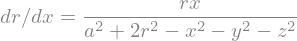

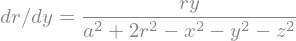

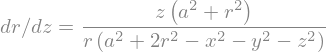

In [2]:
rho2 = x**2 + y**2 + z**2
D = 2*r**2 - rho2 + a**2

dr_dx = x*r / D
dr_dy = y*r / D
dr_dz = z*(r**2 + a**2) / (r*D)

dr = (sp.Integer(0), dr_dx, dr_dy, dr_dz)

display(sp.Eq(sp.Symbol('dr/dx'), dr_dx))
display(sp.Eq(sp.Symbol('dr/dy'), dr_dy))
display(sp.Eq(sp.Symbol('dr/dz'), dr_dz))


### Verify the implicit derivatives

This is a small symbolic check performed once. It confirms that the expressions above satisfy \(dF/dx^i=0\) along the Kerr radial surface.


In [17]:
F = r**4 - (rho2 - a**2)*r**2 - a**2*z**2

checks = []
for k, q in enumerate(coords):
    if k == 0:
        checks.append(sp.Integer(0))
    else:
        total = sp.diff(F, q) + sp.diff(F, r)*dr[k]
        checks.append(sp.cancel(total))

checks


All four entries should be `0` (the first because the geometry is stationary).

## 2. Total spatial derivative operator

For any expression \(f(x,y,z,r)\),

\[
\partial_i f
=
\left.\frac{\partial f}{\partial x^i}\right|_r
+
\frac{\partial f}{\partial r}\frac{\partial r}{\partial x^i}.
\]

This lets us retain compact algebra in \(r\) rather than substituting its nested square root throughout the symbolic derivation.


In [18]:
def total_derivative(expr, k):
    # k = 0,1,2,3 corresponds to t,x,y,z.
    if k == 0:
        return sp.Integer(0)
    return sp.diff(expr, coords[k]) + sp.diff(expr, r)*dr[k]


## 3. Kerr–Schild building blocks

We reuse the same convention as Notebook 01,

\[
\ell_\mu=
\left(
1,
\frac{rx+ay}{r^2+a^2},
\frac{ry-ax}{r^2+a^2},
\frac{z}{r}
\right),
\]

and

\[
H=\frac{Mr^3}{r^4+a^2z^2}.
\]


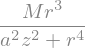

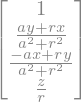

In [19]:
ell_cov = Matrix([
    1,
    (r*x + a*y)/(r**2 + a**2),
    (r*y - a*x)/(r**2 + a**2),
    z/r,
])

ell_contra = eta_inv * ell_cov

H = M*r**3/(r**4 + a**2*z**2)

g_cov = eta + 2*H*(ell_cov*ell_cov.T)
g_contra = eta_inv - 2*H*(ell_contra*ell_contra.T)

display(H)
display(ell_cov)


## 4. Differentiate only \(H\) and \(\ell_\mu\)

Instead of differentiating all sixteen metric components independently, use

\[
\partial_k g_{\mu\nu}
=
2\left[
(\partial_k H)\ell_\mu\ell_\nu
+
H(\partial_k\ell_\mu)\ell_\nu
+
H\ell_\mu(\partial_k\ell_\nu)
\right].
\]

This preserves the Kerr–Schild structure and reduces duplicated symbolic work.


In [20]:
start = time.perf_counter()

dH = [total_derivative(H, k) for k in range(4)]

dell = []
for k in range(4):
    dell.append(Matrix([total_derivative(ell_cov[mu], k) for mu in range(4)]))

derivative_time = time.perf_counter() - start
print(f'Built derivatives of H and ell_mu in {derivative_time:.3f} s')


Built derivatives of H and ell_mu in 0.002 s


In [21]:
start = time.perf_counter()

dg = []
for k in range(4):
    term = 2 * (
        dH[k] * (ell_cov * ell_cov.T)
        + H * (dell[k] * ell_cov.T + ell_cov * dell[k].T)
    )
    dg.append(term)

dg_time = time.perf_counter() - start
print(f'Assembled metric derivatives in {dg_time:.3f} s')


Assembled metric derivatives in 0.009 s


Here `dg[k][mu,nu]` represents

\[
\partial_k g_{\mu\nu}.
\]

Because the spacetime is stationary, `dg[0]` is exactly zero.

## 5. Contract the connection before numerical evaluation

Using the symmetry in the lower Christoffel indices,

\[
\Gamma^\mu_{\alpha\beta}u^\alpha u^\beta
=
g^{\mu\nu}
\left(
\partial_\alpha g_{\nu\beta}
-\frac12\partial_\nu g_{\alpha\beta}
\right)
u^\alpha u^\beta.
\]

We construct this contracted expression directly rather than storing and simplifying 64 separate Christoffel symbols.


In [22]:
ut, ux, uy, uz = sp.symbols('u_t u_x u_y u_z', real=True)
u = Matrix([ut, ux, uy, uz])

start = time.perf_counter()

# First construct Q_nu:
# Q_nu = sum_{alpha,beta} (d_alpha g_{nu,beta}
#                         - 1/2 d_nu g_{alpha,beta}) u^alpha u^beta
Q = []

for nu in range(4):
    expr = sp.Integer(0)
    for alpha in range(4):
        for beta in range(4):
            expr += (
                dg[alpha][nu, beta]
                - sp.Rational(1, 2)*dg[nu][alpha, beta]
            ) * u[alpha] * u[beta]
    Q.append(expr)

Q = Matrix(Q)

# A^mu = -g^{mu nu} Q_nu
A = -(g_contra * Q)

contract_time = time.perf_counter() - start
print(f'Built contracted geodesic acceleration in {contract_time:.3f} s')


Built contracted geodesic acceleration in 0.071 s


We intentionally have **not** called `simplify()` on the four acceleration components.

Instead, first inspect their algebraic operation counts.


In [23]:
raw_ops = [sp.count_ops(A[mu]) for mu in range(4)]
raw_ops


## 6. Flat-spacetime check

When \(M=0\),

\[
H=0,\qquad g_{\mu\nu}=\eta_{\mu\nu},
\]

so all geodesic accelerations must vanish.


In [24]:
flat_A = [A[mu].subs(M, 0) for mu in range(4)]
flat_A


The result should be `[0, 0, 0, 0]`.

## 7. Create the numerical geodesic acceleration

The symbolic function takes \(r\) as an explicit argument. A lightweight numerical wrapper computes the physical Kerr radius once per call.

This is deliberately different from substituting the radical expression for \(r\) into every symbolic term.


In [25]:
start = time.perf_counter()

A_num_core = sp.lambdify(
    (x, y, z, r, ut, ux, uy, uz, M, a),
    A,
    modules='numpy',
    cse=True,
    docstring_limit=0,
)

lambdify_time = time.perf_counter() - start
print(f'lambdify + CSE time: {lambdify_time:.3f} s')


lambdify + CSE time: 0.115 s


In [26]:
def kerr_radius_numeric(xv, yv, zv, av):
    rho2v = xv*xv + yv*yv + zv*zv
    Av = rho2v - av*av
    discv = np.sqrt(Av*Av + 4.0*av*av*zv*zv)
    r2v = 0.5*(Av + discv)
    return np.sqrt(r2v)


def acceleration_numeric(xv, yv, zv, uv, Mv=1.0, av=0.5):
    rv = kerr_radius_numeric(xv, yv, zv, av)

    result = A_num_core(
        xv, yv, zv, rv,
        uv[0], uv[1], uv[2], uv[3],
        Mv, av,
    )

    return np.asarray(result, dtype=float).reshape(4)


### Numerical spot check

At a regular point outside the hole, the result should be finite.


In [27]:
u_test = np.array([1.1, 0.02, 0.12, 0.01])

A_test = acceleration_numeric(
    8.0, 1.5, 0.7,
    u_test,
    Mv=1.0,
    av=0.5,
)

print('A^mu =', A_test)
print('all finite:', np.all(np.isfinite(A_test)))


A^mu = [-0.00579804 -0.01329001 -0.00285391 -0.00114343]
all finite: True


## 8. Numerical Minkowski test

Even through the fully generated numerical kernel, \(M=0\) should give zero acceleration to floating-point precision.


In [28]:
A_flat_num = acceleration_numeric(
    8.0, 1.5, 0.7,
    u_test,
    Mv=0.0,
    av=0.5,
)

print('M=0 acceleration:', A_flat_num)
print('max absolute value:', np.max(np.abs(A_flat_num)))


M=0 acceleration: [0. 0. 0. 0.]
max absolute value: 0.0


## 9. Benchmark the acceleration kernel

This is the benchmark that determines whether we are ready to write RK4.

A fourth-order Runge–Kutta step requires four RHS evaluations, so the per-evaluation cost matters directly.


In [29]:
# Warm-up
_ = acceleration_numeric(8.0, 1.5, 0.7, u_test, 1.0, 0.5)

n_eval = 10_000
start = time.perf_counter()

for _ in range(n_eval):
    acceleration_numeric(8.0, 1.5, 0.7, u_test, 1.0, 0.5)

elapsed = time.perf_counter() - start

print(f'{n_eval:,} acceleration evaluations: {elapsed:.6f} s')
print(f'average per evaluation: {1e6*elapsed/n_eval:.3f} microseconds')
print(f'rough cost of 100,000 RK4 steps: {4*100_000*elapsed/n_eval:.2f} s')


10,000 acceleration evaluations: 0.229036 s
average per evaluation: 22.904 microseconds
rough cost of 100,000 RK4 steps: 9.16 s


## 10. Assemble the eight-dimensional first-order RHS

The state vector will be

\[
Y=
(t,x,y,z,u^t,u^x,u^y,u^z).
\]

The first-order system is

\[
\frac{dx^\mu}{d\lambda}=u^\mu,
\qquad
\frac{du^\mu}{d\lambda}=A^\mu.
\]

This function contains **no SymPy operations**.


In [30]:
def geodesic_rhs(lam, state, Mv=1.0, av=0.5):
    state = np.asarray(state, dtype=float)

    position = state[:4]
    velocity = state[4:]

    acc = acceleration_numeric(
        position[1],
        position[2],
        position[3],
        velocity,
        Mv=Mv,
        av=av,
    )

    rhs = np.empty(8, dtype=float)
    rhs[:4] = velocity
    rhs[4:] = acc
    return rhs


state_test = np.array([
    0.0,       # t
    8.0, 1.5, 0.7,  # x,y,z
    1.1, 0.02, 0.12, 0.01  # u^t,u^x,u^y,u^z
])

geodesic_rhs(0.0, state_test, 1.0, 0.5)


array([ 1.1       ,  0.02      ,  0.12      ,  0.01      , -0.00579804,
       -0.01329001, -0.00285391, -0.00114343])

## Stop here before integrating

Before Notebook 03 writes RK4, record these outputs:

- time to construct \(dH\) and \(d\ell_\mu\),
- time to build the contracted acceleration,
- operation counts,
- `lambdify + CSE` time,
- numerical Minkowski check,
- average acceleration-evaluation time.

If any symbolic cell unexpectedly takes many minutes, interrupt the kernel and report the exact cell. We will optimize that stage rather than allowing a runaway symbolic calculation.

If the benchmark is acceptable, Notebook 03 will:

1. construct physically consistent initial four-velocities,
2. implement our own RK4,
3. compare RK4 with `scipy.integrate.solve_ivp`,
4. monitor \(g_{\mu\nu}u^\mu u^\nu\),
5. test the Schwarzschild \(a=0\) limit,
6. generate the first validated particle trajectories.
